# 

In [42]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Save model
import joblib

In [43]:
# Load dataset
df = pd.read_csv("Super_store.csv")

# View first rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/08/16,11/11/16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/08/16,11/11/16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06/12/16,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/15,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/15,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [44]:
# EDA

# Shape of data
print(df.shape)

# Column names
print(df.columns)

# Data info
df.info()

(9994, 21)
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 


In [45]:
# MISSING VALUES CHECK
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [46]:
# DATE CONVERSION
# Convert date columns
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [47]:
# FEATURE ENGINEERING
# Convert dates
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Extract features
df["order_year"] = df["Order Date"].dt.year
df["order_month"] = df["Order Date"].dt.month
df["order_day"] = df["Order Date"].dt.day

# Shipping duration
df["ship_duration"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [48]:
import os

# Create folder if not exists
os.makedirs("data", exist_ok=True)

# Save cleaned dataset
df.to_csv("data/cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [49]:
# create a copy for ML
df_eda = df.copy()   # for analysis (KEEP ALL COLUMNS)
df_ml = df.copy()    # for model building

In [50]:
# Top Customers
top_customers = df_eda.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)
print(top_customers)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


In [51]:
# Top Products
top_products = df_eda.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


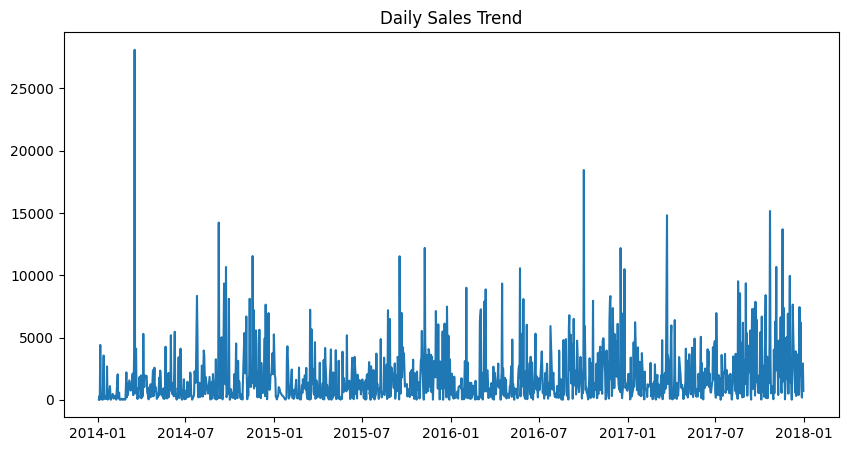

In [52]:
# Daily Sales Trend
daily_sales = df_eda.groupby("Order Date")["Sales"].sum()

import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(daily_sales)
plt.title("Daily Sales Trend")
plt.show()

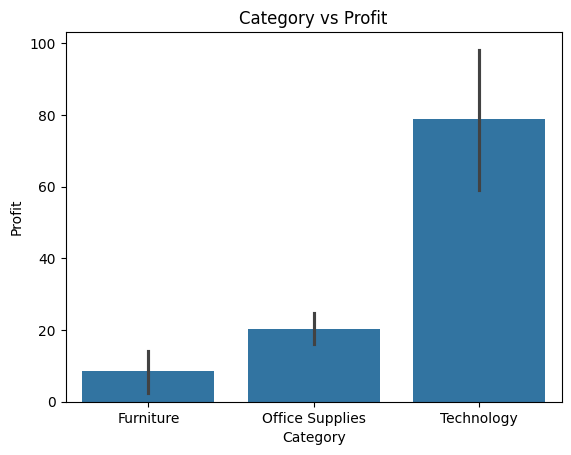

In [53]:
# Profit by Category
import seaborn as sns

plt.figure()
sns.barplot(x="Category", y="Profit", data=df_eda)
plt.title("Category vs Profit")
plt.show()

Drop unnecessary columns for ML model

In [54]:
df_ml.drop(columns=[
    "Row ID",
    "Order ID",
    "Customer ID",
    "Customer Name",   # safe now for ML
    "Product ID",
    "Product Name",    # safe now for ML
    "Order Date",
    "Ship Date"
], inplace=True)

In [56]:
# ENCODING (ML DATA ONLY)
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    "Ship Mode", "Segment", "Country", "City",
    "State", "Region", "Category", "Sub-Category"
]

le = LabelEncoder()

for col in categorical_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

In [57]:
# SPLIT DATA
X = df_ml.drop("Profit", axis=1)
y = df_ml["Profit"]

In [58]:
# TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [59]:
# MODEL TRAINING
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [60]:
# PREDICTION
y_pred = model.predict(X_test)

In [62]:
# EVALUATION
from sklearn.metrics import r2_score, mean_squared_error

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: -0.04502284840175852
RMSE: 225.0956779469587


In [63]:
# Save Model
import joblib

joblib.dump(model, "models/superstore_profit_model.pkl")

['models/superstore_profit_model.pkl']